In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

ML_DIR = Path.cwd().parent
CACHE = ML_DIR / "data" / "cached"
IMG_DIR = ML_DIR / "data" / "raw" / "fashion-dataset" / "images"

emb = np.load(CACHE / "clip_image_embeddings.npy")
ids = np.load(CACHE / "clip_image_ids.npy")
meta = pd.read_csv(CACHE / "metadata_clean.csv")

# map id -> row index for fast lookup
id_to_idx = {int(i): k for k, i in enumerate(ids)}

print("embeddings:", emb.shape, emb.dtype)
print("ids:", ids.shape)
print("metadata:", meta.shape)

# sanity: are embeddings actually l2-normalized?
norms = np.linalg.norm(emb, axis=1)
print(f"norm stats - min: {norms.min():.4f}, max: {norms.max():.4f}, mean: {norms.mean():.4f}")

embeddings: (44419, 512) float32
ids: (44419,)
metadata: (44419, 11)
norm stats - min: 1.0000, max: 1.0000, mean: 1.0000


In [2]:
def search(query_id, top_k=10):
    """given a product id, return top_k most similar product ids (excluding self)."""
    idx = id_to_idx[query_id]
    query_vec = emb[idx]
    # since vectors are l2-normalized, dot product = cosine similarity
    sims = emb @ query_vec  # (44419,)
    top_indices = np.argpartition(-sims, top_k + 1)[:top_k + 1]
    top_indices = top_indices[np.argsort(-sims[top_indices])]
    # remove self (the query itself)
    top_indices = [i for i in top_indices if ids[i] != query_id][:top_k]
    return [(int(ids[i]), float(sims[i])) for i in top_indices]


def show_results(query_id, top_k=8):
    """visualize query + top_k neighbors."""
    results = search(query_id, top_k=top_k)

    fig, axes = plt.subplots(1, top_k + 1, figsize=(2 * (top_k + 1), 3))

    # query
    q_meta = meta[meta['id'] == query_id].iloc[0]
    q_img = Image.open(IMG_DIR / f"{query_id}.jpg")
    axes[0].imshow(q_img)
    axes[0].set_title(f"QUERY\n{q_meta['articleType']}\n{q_meta['baseColour']}", fontsize=8, color='red')
    axes[0].axis('off')

    # results
    for ax, (rid, sim) in zip(axes[1:], results):
        r_meta = meta[meta['id'] == rid].iloc[0]
        r_img = Image.open(IMG_DIR / f"{rid}.jpg")
        ax.imshow(r_img)
        ax.set_title(f"sim={sim:.3f}\n{r_meta['articleType']}\n{r_meta['baseColour']}", fontsize=7)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


query id: 16947


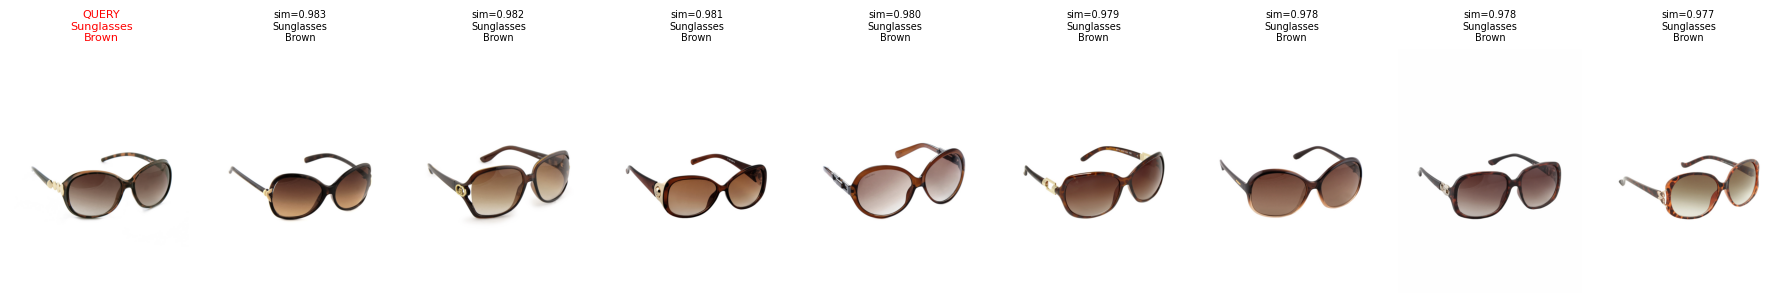


query id: 40524


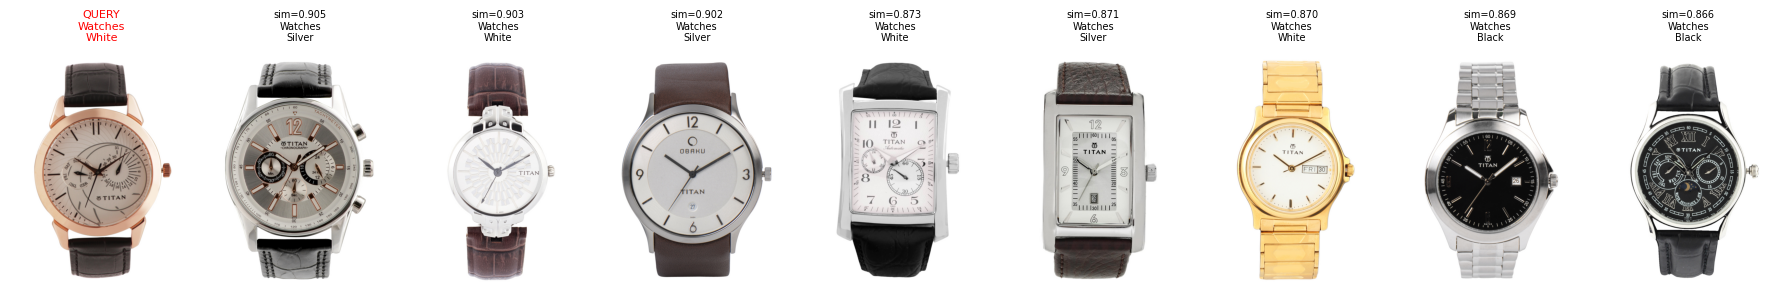


query id: 36313


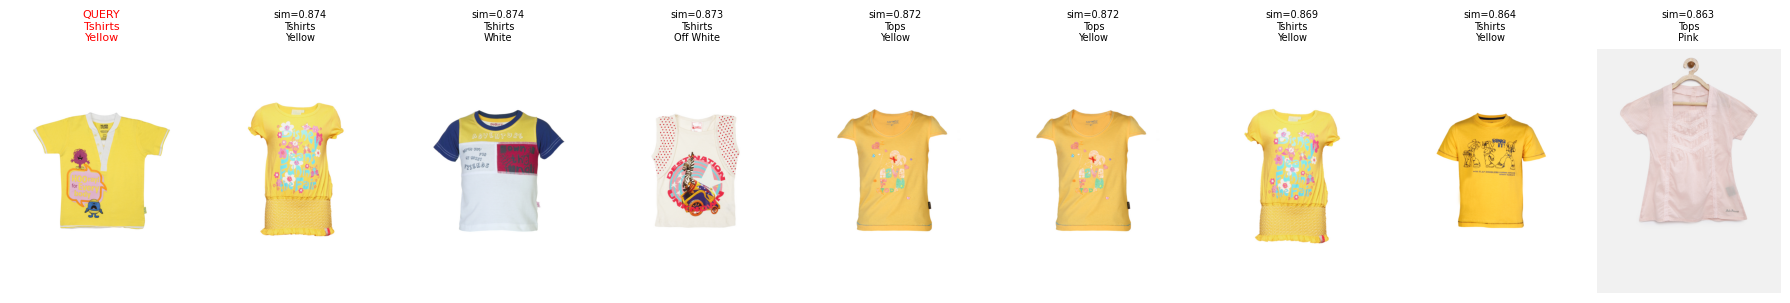


query id: 44188


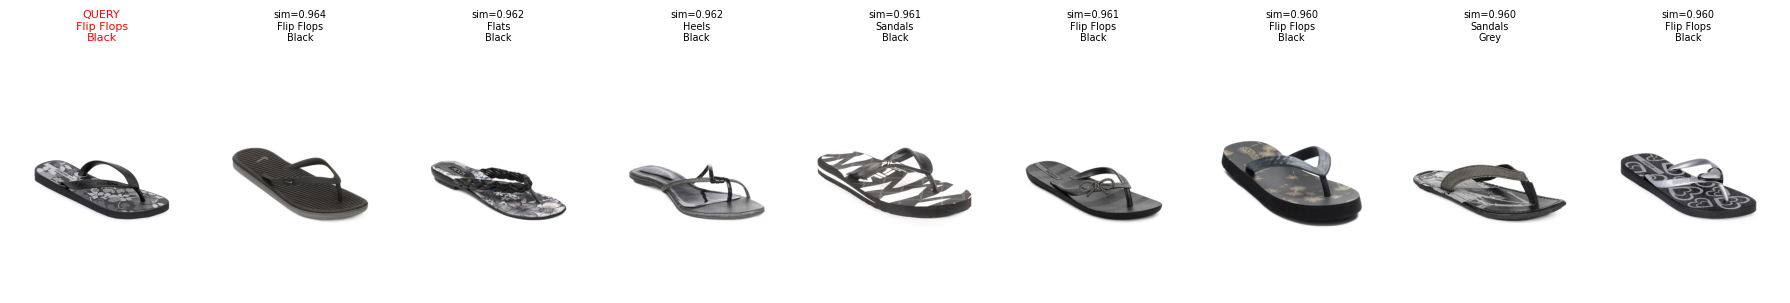


query id: 33859


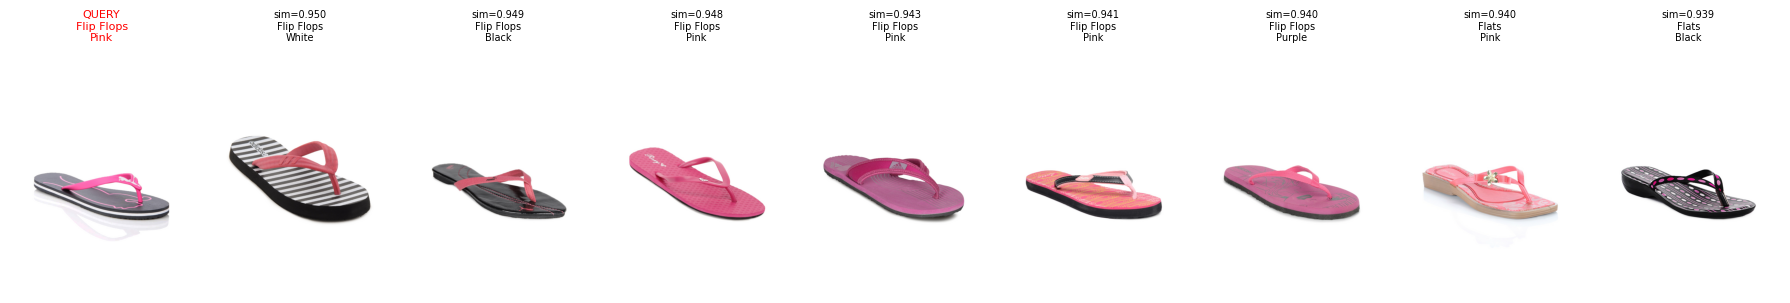

In [3]:
np.random.seed(42)
sample_ids = np.random.choice(ids, 5, replace=False)
for qid in sample_ids:
    print(f"\nquery id: {qid}")
    show_results(int(qid), top_k=8)

In [4]:
def category_match_at_k(num_queries=500, k=5, seed=0):
    """for random queries, measure how often top-k contains items with matching articleType."""
    np.random.seed(seed)
    sample_idx = np.random.choice(len(ids), num_queries, replace=False)
    match_count = 0
    color_match_count = 0
    for i in sample_idx:
        qid = int(ids[i])
        q_meta = meta[meta['id'] == qid].iloc[0]
        results = search(qid, top_k=k)
        result_ids = [r[0] for r in results]
        result_meta = meta[meta['id'].isin(result_ids)]
        if (result_meta['articleType'] == q_meta['articleType']).any():
            match_count += 1
        if (result_meta['baseColour'] == q_meta['baseColour']).any():
            color_match_count += 1
    print(f"queries: {num_queries}, top-{k}")
    print(f"  article type match rate: {match_count / num_queries:.3f}")
    print(f"  color match rate:        {color_match_count / num_queries:.3f}")


category_match_at_k(num_queries=500, k=5)
category_match_at_k(num_queries=500, k=10)

queries: 500, top-5
  article type match rate: 0.966
  color match rate:        0.784
queries: 500, top-10
  article type match rate: 0.978
  color match rate:        0.874
